# GANs in PyTorch: from notation to training

**Workshop time:** about 60–70 minutes.

We observe

$$
\{X_1,\ldots,X_n\}, \qquad X_i\in\mathbb{R}^d,
$$

and seek a generator

$$
G_\theta:\mathbb{R}^{d'}\to\mathbb{R}^d
$$

such that, for a latent random vector $Z\sim\pi$,

$$
\widetilde X = G_\theta(Z)\overset{d}{\simeq}X.
$$

A discriminator

$$
D_\phi:\mathbb{R}^d\to[0,1]
$$

tries to distinguish observations from the data distribution from observations produced by the generator.

The classical GAN objective is

$$
\min_{\theta}\max_{\phi}
\left[
\mathbb E_{p_X}\{\log D_\phi(X)\}
+
\mathbb E_{p_Z}\{\log(1-D_\phi(G_\theta(Z)))\}
\right].
$$

## Learning objectives

By the end of the practical you should be able to:

1. identify $X$, $Z$, $G_\theta$, $D_\phi$, $d$, and $d'$ in PyTorch code;
2. construct generator and discriminator neural networks;
3. translate the GAN minimax objective into alternating optimisation steps;
4. train a GAN using `torch`;
5. compare the observed and generated distributions.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.2.1
Device: mps


# 1. Observed data $X_1,\ldots,X_n$

We use a deliberately simple one-dimensional target distribution so that we can inspect the fit visually.

The GAN is **not** given the density below. It sees only the sampled observations.

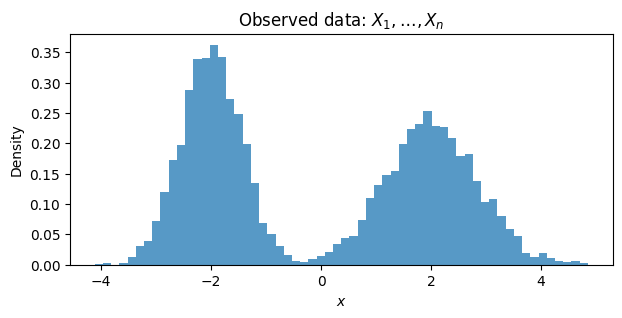

In [2]:
n = 6000

component = torch.bernoulli(
    torch.full((n, 1), 0.5)
)

X = torch.where(
    component == 0,
    -2.0 + 0.55 * torch.randn(n, 1),
     2.0 + 0.85 * torch.randn(n, 1)
)

plt.figure(figsize=(7, 3))
plt.hist(
    X.numpy().ravel(),
    bins=60,
    density=True,
    alpha=0.75
)
plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title(r"Observed data: $X_1,\ldots,X_n$")
plt.show()

# 2. Choose the latent distribution $\pi$

For this example,

$$
d=1,\qquad d'=1,\qquad Z\sim N(0,1).
$$

The latent variable $Z$ provides simple random input. The generator transforms it into a sample that should resemble $X$.

In [3]:
d = 1
d_prime = 1
J = 32

def sample_Z(n):
    return torch.randn(
        n,
        d_prime,
        device=device
    )

Z = sample_Z(5)
print("Z shape:", Z.shape)
print(Z)

Z shape: torch.Size([5, 1])
tensor([[ 2.2035],
        [ 0.4599],
        [ 0.5828],
        [-0.5727],
        [-1.7389]], device='mps:0')


# 3. Construct $G_\theta$ and $D_\phi$

The notation for a one-hidden-layer ReLU generator is

$$
G_\theta^{(m)}(z)
=
\sum_{j=1}^{J}
a_j^{(m)}
\sigma^R\left(
\sum_{i=1}^{d'} w_j^{(i)}z^{(i)}+b_j
\right)
+c^{(m)},
$$

with

$$
\sigma^R(x)=\max(0,x).
$$

In PyTorch:

- `nn.Linear` contains weights and biases;
- `nn.ReLU()` applies $\sigma^R$;
- the final `Linear` layer maps to $\mathbb R^d$.

For the practical we use **two hidden ReLU layers** in both networks. 

The discriminator returns a **logit**
$s_\phi(x)\in\mathbb R$.
When needed,

$$
D_\phi(x)=\operatorname{sigmoid}(s_\phi(x)).
$$

In [4]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_prime, J),
            nn.ReLU(),
            nn.Linear(J, J),
            nn.ReLU(),
            nn.Linear(J, d)
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, J),
            nn.ReLU(),
            nn.Linear(J, J),
            nn.ReLU(),
            nn.Linear(J, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


G = Generator().to(device)
D = Discriminator().to(device)

print("Generator G_theta:")
print(G)

print("\nDiscriminator D_phi:")
print(D)

Generator G_theta:
Generator(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Discriminator D_phi:
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Check the dimensions

A batch of latent variables has shape

$$
(\text{batch size},d'),
$$

and the generated data have shape

$$
(\text{batch size},d).
$$

In [5]:
with torch.no_grad():
    X_tilde = G(Z)
    prob_real = torch.sigmoid(D(X_tilde))

print("Z shape:", Z.shape)
print("G_theta(Z) shape:", X_tilde.shape)
print("D_phi(G_theta(Z)):", prob_real)

Z shape: torch.Size([5, 1])
G_theta(Z) shape: torch.Size([5, 1])
D_phi(G_theta(Z)): tensor([0.4730, 0.4736, 0.4737, 0.4722, 0.4700], device='mps:0')


# 4. From the minimax objective to training

Training alternates between two updates. The classical GAN objective is

$$
\min_{\theta}\max_{\phi}
\left[
\mathbb E_{p_X}\{\log D_\phi(X)\}
+
\mathbb E_{p_Z}\{\log(1-D_\phi(G_\theta(Z)))\}
\right].
$$

### Update the discriminator parameters $\phi$

We want

$$
D_\phi(X)\approx1
$$

for real data and

$$
D_\phi(G_\theta(Z))\approx0
$$

for generated data.

### Update the generator parameters $\theta$

Instead of the saturating minimax generator loss,

$$
\min_{\theta}\mathbb E_{p_Z}\left[\{\log(1-D_\phi(G_\theta(Z)))\}
\right],
$$
we use the standard **non-saturating** loss

$$
\mathcal L_G
=
-\mathbb E_{p_Z}
\left[
\log D_\phi(G_\theta(Z))
\right].
$$

This has the same desired equilibrium but provides stronger gradients early in training.

`BCEWithLogitsLoss` combines the sigmoid and binary cross-entropy calculations in a numerically stable way.

In [6]:
batch_size = 128

loader = DataLoader(
    TensorDataset(X),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

criterion = nn.BCEWithLogitsLoss()

opt_D = torch.optim.Adam(
    D.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

opt_G = torch.optim.Adam(
    G.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

# 5. Train the GAN

The entire adversarial update is kept in one loop.

The key detail is

```python
x_fake = G(z).detach()
```

during the discriminator update: $\phi$ should change, but $\theta$ should not.

In [36]:
epochs = 80
history_D = []
history_G = []

for epoch in range(epochs):
    d_losses = []
    g_losses = []

    for (x_real,) in loader:
        x_real = x_real.to(device)
        batch_n = x_real.shape[0]

        # --------------------------------
        # 1. Update discriminator phi
        # --------------------------------
        z = sample_Z(batch_n)
        x_fake = G(z).detach()

        real_logits = D(x_real)
        fake_logits = D(x_fake)

        loss_D = (
            criterion(
                real_logits,
                torch.ones_like(real_logits)
            )
            +
            criterion(
                fake_logits,
                torch.zeros_like(fake_logits)
            )
        )

        opt_D.zero_grad() #clear gradients
        loss_D.backward() #backpropagation
        opt_D.step() #update

        # --------------------------------
        # 2. Update generator theta
        # --------------------------------
        z = sample_Z(batch_n)
        x_fake = G(z)
        fake_logits = D(x_fake)

        loss_G = criterion(
            fake_logits,
            torch.ones_like(fake_logits)
        )

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        d_losses.append(loss_D.item())
        g_losses.append(loss_G.item())

    history_D.append(np.mean(d_losses))
    history_G.append(np.mean(g_losses))

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch+1:3d}/{epochs} | "
            f"loss_D = {history_D[-1]:.3f} | "
            f"loss_G = {history_G[-1]:.3f}"
        )

Epoch  20/80 | loss_D = 1.335 | loss_G = 0.705
Epoch  40/80 | loss_D = 1.335 | loss_G = 0.766
Epoch  60/80 | loss_D = 1.362 | loss_G = 0.733
Epoch  80/80 | loss_D = 1.370 | loss_G = 0.717


# 6. Diagnostics

GAN losses do not behave like an ordinary regression loss: neither is expected simply to decrease to zero.

A useful evaluation combines the training losses with direct comparison of the real and generated samples.

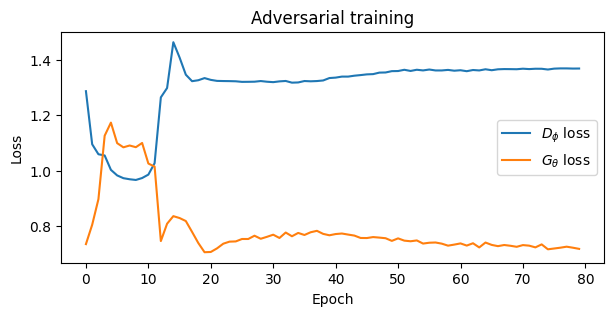

In [37]:
plt.figure(figsize=(7, 3))
plt.plot(history_D, label=r"$D_\phi$ loss")
plt.plot(history_G, label=r"$G_\theta$ loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adversarial training")
plt.legend()
plt.show()

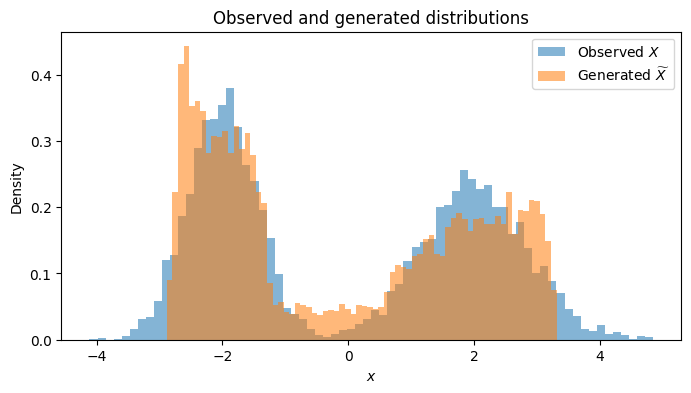

In [38]:
G.eval()

with torch.no_grad():
    X_fake = G(
        sample_Z(10_000)
    ).cpu().numpy().ravel()

X_real = X.numpy().ravel()

plt.figure(figsize=(8, 4))
plt.hist(
    X_real,
    bins=70,
    density=True,
    alpha=0.55,
    label=r"Observed $X$"
)
plt.hist(
    X_fake,
    bins=70,
    density=True,
    alpha=0.55,
    label=r"Generated $\widetilde X$"
)
plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title(r"Observed and generated distributions")
plt.legend()
plt.show()

## Inspect the learned map $G_\theta$

Because $d=d'=1$, we can plot the generator directly as a function of $z$.

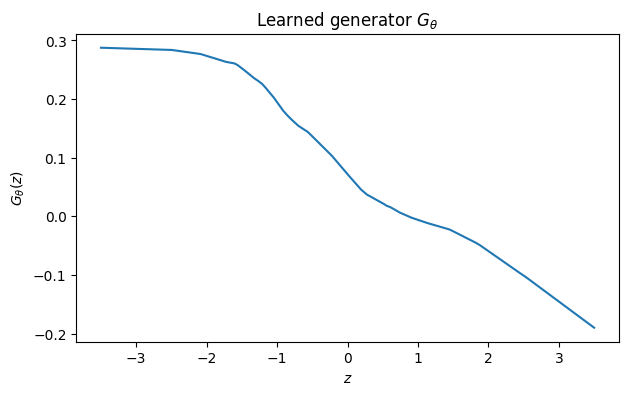

In [7]:
z_grid = torch.linspace(
    -3.5,
    3.5,
    600,
    device=device
).reshape(-1, 1)

with torch.no_grad():
    g_grid = G(z_grid).cpu().numpy().ravel()

plt.figure(figsize=(7, 4))
plt.plot(
    z_grid.cpu().numpy().ravel(),
    g_grid
)
plt.xlabel(r"$z$")
plt.ylabel(r"$G_\theta(z)$")
plt.title(r"Learned generator $G_\theta$")
plt.show()

# 7. Discussion and exercises

Try one change at a time.

1. **Latent distribution:** replace $Z\sim N(0,1)$ with $Z\sim U(-1,1)$.
2. **Network width:** change $J$ from 32 to 8 or 128.
3. **Network depth:** remove one hidden layer from $G_\theta$.
4. **Discriminator strength:** give $D_\phi$ two updates for every generator update.
5. **Mode collapse:** repeat training with several random seeds.
6. **Heavy tails:** replace the bimodal data with a Student-$t$ sample and inspect the generated tail.

Questions to discuss:

- What does it mean for the discriminator to become "too good"?
- Why might the generator learn only one mode?
- Why are generated-sample plots often more informative than the raw GAN losses?
- How would you decide whether
  $G_\theta(Z)\overset{d}{\simeq}X$
  is an adequate approximation?

# 8. Extension: a two-dimensional GAN

We now repeat the same construction with

$$
X\in\mathbb R^2.
$$

The aim is to show that the GAN training algorithm is essentially unchanged when we move from one-dimensional to multivariate data. The main changes are the dimensions of the generator and discriminator.

We use a four-mode bivariate distribution and choose

$$
d'=3,\qquad d=2.
$$

The notation and training steps are exactly the same:

$$
Z \sim \pi
\quad\longrightarrow\quad
\widetilde X = G_\theta(Z)
\quad\longrightarrow\quad
D_\phi(\widetilde X).
$$


## 8.1 Simulate observations $X_1,\ldots,X_n\in\mathbb R^2$

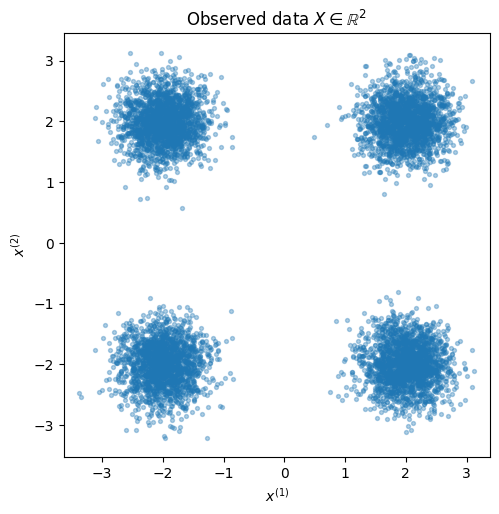

In [8]:
n = 8000
centres = torch.tensor([
    [-2.0, -2.0],
    [-2.0,  2.0],
    [ 2.0, -2.0],
    [ 2.0,  2.0]
])

labels = torch.randint(0, 4, (n,))
X = centres[labels] + 0.35 * torch.randn(n, 2)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(X[:, 0], X[:, 1], s=8, alpha=0.35)
plt.xlabel(r"$x^{(1)}$")
plt.ylabel(r"$x^{(2)}$")
plt.title(r"Observed data $X\in\mathbb{R}^2$")
plt.axis("equal")
plt.show()

## 8.2 Generator and discriminator

We choose

$$
d'=3,\qquad d=2.
$$

Thus the generator maps a three-dimensional latent vector into a two-dimensional observation, exactly matching the dimensions in the diagram on p. 7. We use more than $J=4$ hidden units here so that training is easier to observe in a short practical.

In [9]:
d_prime = 3
d = 2
J = 64

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_prime, J),
            nn.ReLU(),
            nn.Linear(J, J),
            nn.ReLU(),
            nn.Linear(J, d)
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, J),
            nn.LeakyReLU(0.2),
            nn.Linear(J, J),
            nn.LeakyReLU(0.2),
            nn.Linear(J, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

G = Generator().to(device)
D = Discriminator().to(device)

print(G)
print(D)

Generator(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [10]:
def sample_Z(n):
    return torch.randn(n, d_prime, device=device)

batch_size = 256
loader = DataLoader(TensorDataset(X), batch_size=batch_size,
                    shuffle=True, drop_last=True)

criterion = nn.BCEWithLogitsLoss()
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))

## 8.3 A compact training loop

Each batch has two phases.

### Phase A: update $\phi$

Maximise the discriminator's ability to separate

$$
X\sim p_X
\quad\text{from}\quad
\widetilde X=G_\theta(Z).
$$

### Phase B: update $\theta$

Change the generator so that the discriminator treats $G_\theta(Z)$ as real.

In [ ]:
def train_gan(epochs=150):
    history = {"D": [], "G": []}

    for epoch in range(epochs):
        d_epoch, g_epoch = [], []

        for (x_real,) in loader:
            x_real = x_real.to(device)
            batch_n = x_real.shape[0]

            # ---- Update discriminator phi ----
            z = sample_Z(batch_n)
            x_fake = G(z).detach()

            real_logits = D(x_real)
            fake_logits = D(x_fake)

            loss_D = (
                criterion(real_logits, torch.ones_like(real_logits))
                + criterion(fake_logits, torch.zeros_like(fake_logits))
            )

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # ---- Update generator theta ----
            z = sample_Z(batch_n)
            x_fake = G(z)
            fake_logits = D(x_fake)

            loss_G = criterion(fake_logits, torch.ones_like(fake_logits))

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            d_epoch.append(loss_D.item())
            g_epoch.append(loss_G.item())

        history["D"].append(np.mean(d_epoch))
        history["G"].append(np.mean(g_epoch))

        if (epoch + 1) % 30 == 0:
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"loss_D={history['D'][-1]:.3f} | "
                f"loss_G={history['G'][-1]:.3f}"
            )

    return history

history = train_gan()

## 8.4 Compare real and generated samples

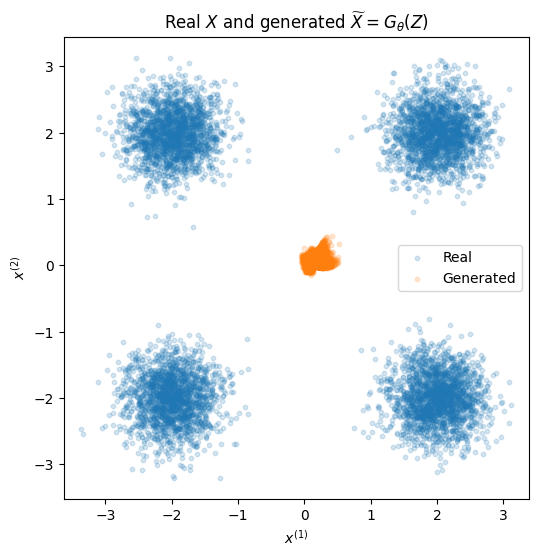

In [11]:
with torch.no_grad():
    X_fake = G(sample_Z(8000)).cpu()

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.18, label="Real")
plt.scatter(X_fake[:, 0], X_fake[:, 1], s=10, alpha=0.18, label="Generated")
plt.xlabel(r"$x^{(1)}$")
plt.ylabel(r"$x^{(2)}$")
plt.title(r"Real $X$ and generated $\widetilde X=G_\theta(Z)$")
plt.axis("equal")
plt.legend()
plt.show()

In [12]:
plt.figure(figsize=(7, 3))
plt.plot(history["D"], label=r"$D_\phi$ loss")
plt.plot(history["G"], label=r"$G_\theta$ loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()
plt.show()

NameError: name 'history' is not defined

<Figure size 700x300 with 0 Axes>

## 8.5 Look at the discriminator

A well-balanced GAN should eventually make discrimination difficult. We can inspect $D_\phi(x)$ over a grid.

Values near 1 indicate "real"; values near 0 indicate "generated".

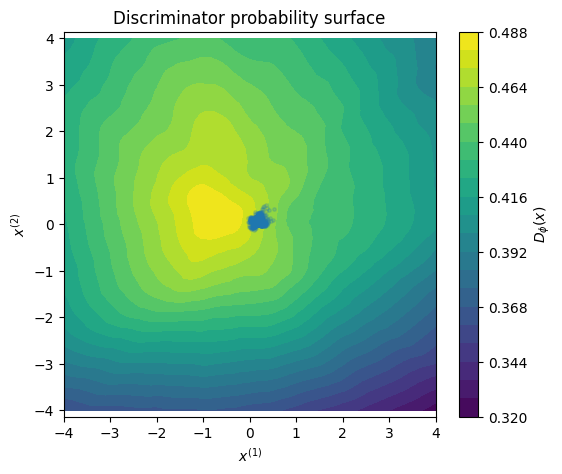

In [13]:
grid_1 = torch.linspace(-4, 4, 150)
grid_2 = torch.linspace(-4, 4, 150)
xx, yy = torch.meshgrid(grid_1, grid_2, indexing="xy")
grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1).to(device)

with torch.no_grad():
    p_real = torch.sigmoid(D(grid)).cpu().reshape(150, 150)

plt.figure(figsize=(6, 5))
plt.contourf(xx.numpy(), yy.numpy(), p_real.numpy(), levels=20)
plt.colorbar(label=r"$D_\phi(x)$")
plt.scatter(X_fake[:1000, 0], X_fake[:1000, 1], s=6, alpha=0.2)
plt.xlabel(r"$x^{(1)}$")
plt.ylabel(r"$x^{(2)}$")
plt.title("Discriminator probability surface")
plt.axis("equal")
plt.show()

## 8.6 Workshop experiments

Try these one at a time.

**A. Latent dimension.** Set $d'=1$. Can a one-dimensional latent variable reproduce this two-dimensional distribution well?

**B. Network width.** Set $J=4$, matching the small architecture in the slide diagram. What changes?

**C. Discriminator strength.** Give the discriminator two or three updates for every generator update. Does training improve or become less stable?

**D. Mode collapse.** Repeat training with several random seeds. Does the generator always learn all four modes?

**E. Latent distribution.** Replace the Gaussian $\pi$ with a uniform distribution.

These experiments connect directly to the slide questions: *How should $\pi$ and $d'$ be chosen? How should $G$ be built?*